# 📊 Eksplorasi Data Intervensi Stunting

Notebook ini digunakan untuk melakukan eksplorasi data (EDA) terhadap dataset intervensi stunting tahun 2023. 

## 🎯 Tujuan Analisis
1. Memahami distribusi dan karakteristik data stunting
2. Menganalisis hubungan antar variabel
3. Mendeteksi anomali dan pola dalam data
4. Mempersiapkan data untuk modeling

## 📋 Outline
1. Setup dan Import Library
2. Load dan Overview Data
3. Analisis Variabel Target (Skor Efektivitas)
4. Analisis Anggaran
5. Analisis Variabel Kategorikal
6. Analisis Korelasi
7. Feature Engineering
8. Kesimpulan

## 1️⃣ Setup dan Import Library

Import library yang diperlukan dan setup environment untuk analisis data.

In [21]:
# Import library standar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

# Import modul custom
import sys
sys.path.append('..')
from src.encoder_utils import normalize_kategorikal

# Setup plotting
sns.set_theme()  # Use seaborn's default theme
sns.set_palette("husl")
%matplotlib inline

# Setup display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

## 2️⃣ Load dan Overview Data

### Data Source
Dataset yang digunakan adalah data intervensi stunting tahun 2023 yang telah diberi label efektivitas. Data ini mencakup berbagai program dan indikator terkait pencegahan stunting di tingkat desa.

In [22]:
# Path konfigurasi
DATA_PATH = "../data/stunting_2023_labeled.csv"

# Load dataset
df = pd.read_csv(DATA_PATH)

# Tampilkan dimensi dataset
print("📏 Dimensi Dataset:", df.shape)
print("\n📋 Preview Dataset:")
display(df.head())

# Info dataset
print("\n📊 Info Dataset:")
display(df.info())

# Statistik deskriptif
print("\n📈 Statistik Deskriptif:")
display(df.describe())

📏 Dimensi Dataset: (75264, 73)

📋 Preview Dataset:


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,a._Total_Remaja_Putri,b._Remaja_Putri_Status_Gizi_Normal_di_desa,c._Remaja_Putri_Status_Anemia_(Hb)_di_desa,Total_Calon_Pengantin_dan_calon_Pasangan_usia_Subur_di_desa,a._Total_Ibu_Hamil,b._Jumlah_Kondisi_Ibu_Hamil_Kondisi_Normal,c._Jumlah_Kondisi_Ibu_Hamil_Kondisi_Kesesahan_KEK,a._Jumlah_Bayi_Usia_0-59_Bulan,b._Jumlah_Bayi_Usia_0-59_Bulan_Status_Gizi_Normal,c._Jumlah_Bayi_Usia_0-59_Bulan_Status_Gizi_Kurang,d._Jumlah_Bayi_Usia_0-59_Bulan_Status_Gizi_Buruk,e._Jumlah_Bayi_Usia_0-59_Bulan_Status_Stunting,a._Total_Keluarga_Beresiko_Stunting_dan_Keluarga_rentan,b._Jumlah_Keluarga_Kategori_Rentan,a._Jumlah_Remaja_Putri_Ikut_Pemeriksaan_Anemia_(Hb),b._Jumlah_Remaja_Putri_Mendapat_Tablet_Tambah_Darah_(TTB),a._Jumlah_Calon_Pengantin_Periksa_Kesehatan,b._Jumlah_Calon_Pengantin_Mengikuti_Bimbingan_Persiapan_Perkawinan,a._Jumlah_Ibu_Hamil_Periksa_Kehamilan/Nifas,b._Jumlah_Ibu_Hamil_Peserta_Keluarga_Berencana_(KB)_Paksa_Persalinan,c._Jumlah_Ibu_Hamil_KEK_mendapatkan_Tambahan_Asupan_Gizi,d._Jumlah_Ibu_Hamil_mengkonsumsi_tablet_tambah_darah_(TTD)_(minimal_90_tablet_selama_masa_kehamilan),a._Jumlah_Anak_usia_0-59_Bulan_terpantau_tumbuh_kembang_(datang_ke_posyandu/layanan_kesehatan_lainnya),b._Jumlah_anak_usia_0-59_bulan_mengikuti_kegiatan_BKB/PAUD,c._Jumlah_Anak_usia_0-59_Bulan_mengalami_gizi_kurang/buruk/stunting_mendapatkan_tambahan_asupan_gizi_dan_konseling_gizi,d._Jumlah_Anak_usia_0-59_bulan_mendapatkan_imunisasi_dasar_lengkap,a._Jumlah_Keluarga_beresiko_stunting_dan_keluarga_rentan_memiliki_kartu_keluarga,b._Jumlah_Keluarga_beresiko_stunting_dan_keluarga_rentan_memiliki_akses_ke_sumber_air_bersih/minum,c._Jumlah_Keluarga_beresiko_stunting_dan_keluarga_rentan_memiliki_akses_ke_jamban_sehat.,d._Jumlah_Keluarga_beresiko_stunting_dan_keluarga_rentan_memiliki_kepesertaan_jaminan_kesehatan_(mandiri/subsidi),e._Jumlah_Keluarga_rentan_(sosial/ekonomi/difabel)_terdaftar_sebagai_peserta_program_bantuan_sosial_(PKH/BLT-DD/Program_sejenis),f._Jumlah_Keluarga_beresiko_stunting_dan_keluarga_rentan_memiliki_akses_sanitasi/pembuangan_limbah_layak,g._Jumlah_Keluarga_beresiko_stunting_mendapat_pendampingan_oleh_TPK,h._Jumlah_Keluarga_beresiko_Stunting_menjadi_peserta_kegiatan_ketahanan_pangan_keluarga/pemanfaatan_lahan_pekarangan_untuk_peningkatan_asupan_gizi,a._Total_Layanan_Remaja_Putri,b._Total_Layanan_Remaja_Putri_diterima,a._Total_Layanan_Calon_Pengantin_dan_calon_pasangan_usia_subur,b._Total_Layanan_Calon_Pengantin_dan_calon_pasangan_usia_subur_diterima,a._Total_Layanan_Ibu_Hamil_dan_ibu_hamil_KEK,b._Total_Layanan_Ibu_Hamil_dan_ibu_hamil_KEK_diterima,a._Total_Layanan_Anak_(0-59_bulan),b._Total_Layanan_Anak_(0-59_bulan)_diterima,a._Total_Layanan_Keluarga_memiliki_sasaran_stunting_dan_keluarga_beresiko_stunting,b._Total_Layanan_Keluarga_memiliki_sasaran_stunting_dan_keluarga_beresiko_stunting_diterima,a._Total_Layanan_Konvergensi_Stunting_di_Desa,b._Total_Layanan_Konvergensi_Stunting_yang_diterima_di_Desa,Desa_Melaksanakan_rembuk_stunting_desa_dengan_melibatkan_UPTD,Terdapat_Penetapan_anggaran__kegiatan_stunting_dalam_APB_Desa,Jumlah_alokasi_anggaran_untuk_mendukung_kegiatan_stunting,Terdapat_Pembentukan_RDS/TPPS,"Terdapat_Pelaku_Desa_(Kader,_KPM,_TPK)_mendapatkan_peningkatan_kapasitas",Aktivitas_rutin_Penyelenggaraan_posyandu_,Aktivitas_rutin_Penyelenggaraan_kelas_Bina_Keluarga_Balita_,Aktivitas_rutin_Penyelenggaraan_PAUD,Terdapat_Pengembangan_Program_Ketahanan_Pangan,RDS/TPPS_mengadakan_rapat_koordinasi,Desa_melakukan_monitoring/evaluasi_atas_pelaksanaan_konvergensi_stunting_min._2_kali_dlm_1tahun,Kendala_yang_dihadapi_(Jelaskan),NAMA_KABUPATEN,NAMA_KECAMATAN,KODE_DESA,NAMA_DESA,skor,label_efektivitas
0,11.00,ACEH,1101.00,ACEH SELATAN,110101.00,BAKONGAN,1101012002.00,UJONG MANGKI,2023.00,39.00,39.00,0.00,5.00,6.00,5.00,1.00,51.00,51.00,0.00,0.00,0.00,6.00,1.00,39.00,39.00,5.00,5.00,0.00,4.00,1.00,4.00,44.00,44.00,44.00,0.00,6.00,5.00,6.00,6.00,0.00,0.


📊 Info Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75264 entries, 0 to 75263
Data columns (total 73 columns):
 #   Column                                                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                                                              --------------  -----  
 0   Unnamed: 0                                                                                                                                          75264 non-null  float64
 1   Unnamed: 1                                                                                                                                          75264 non-null  object 
 2   Unnamed: 2                                                                                                                                          75264 non-nul

None


📈 Statistik Deskriptif:


,Unnamed: 0,Unnamed: 2,Unnamed: 4,Unnamed: 6,Unnamed: 8,a._Total_Remaja_Putri,b._Remaja_Putri_Status_Gizi_Normal_di_desa,c._Remaja_Putri_Status_Anemia_(Hb)_di_desa,Total_Calon_Pengantin_dan_calon_Pasangan_usia_Subur_di_desa,a._Total_Ibu_Hamil,b._Jumlah_Kondisi_Ibu_Hamil_Kondisi_Normal,c._Jumlah_Kondisi_Ibu_Hamil_Kondisi_Kesesahan_KEK,a._Jumlah_Bayi_Usia_0-59_Bulan,b._Jumlah_Bayi_Usia_0-59_Bulan_Status_Gizi_Normal,c._Jumlah_Bayi_Usia_0-59_Bulan_Status_Gizi_Kurang,d._Jumlah_Bayi_Usia_0-59_Bulan_Status_Gizi_Buruk,e._Jumlah_Bayi_Usia_0-59_Bulan_Status_Stunting,a._Total_Keluarga_Beresiko_Stunting_dan_Keluarga_rentan,b._Jumlah_Keluarga_Kategori_Rentan,a._Jumlah_Remaja_Putri_Ikut_Pemeriksaan_Anemia_(Hb),b._Jumlah_Remaja_Putri_Mendapat_Tablet_Tambah_Darah_(TTB),a._Jumlah_Calon_Pengantin_Periksa_Kesehatan,b._Jumlah_Calon_Pengantin_Mengikuti_Bimbingan_Persiapan_Perkawinan,a._Jumlah_Ibu_Hamil_Periksa_Kehamilan/Nifas,b._Jumlah_Ibu_Hamil_Peserta_Keluarga_Berencana_(KB)_Paksa_Persalinan,c._Jumlah_Ibu_Hamil_KEK_mendapatkan_Tambahan_Asupan_Gizi,d._Jumlah_Ibu_Hamil_mengkonsumsi_tablet_tambah_darah_(TTD)_(minimal_90_tablet_selama_masa_kehamilan),a._Jumlah_Anak_usia_0-59_Bulan_terpantau_tumbuh_kembang_(datang_ke_posyandu/layanan_kesehatan_lainnya),b._Jumlah_anak_usia_0-59_bulan_mengikuti_kegiatan_BKB/PAUD,c._Jumlah_Anak_usia_0-59_Bulan_mengalami_gizi_kurang/buruk/stunting_mendapatkan_tambahan_asupan_gizi_dan_konseling_gizi,d._Jumlah_Anak_usia_0-59_bulan_mendapatkan_imunisasi_dasar_lengkap,a._Jumlah_Keluarga_beresiko_stunting_dan_keluarga_rentan_memiliki_kartu_keluarga,b._Jumlah_Keluarga_beresiko_stunting_dan_keluarga_rentan_memiliki_akses_ke_sumber_air_bersih/minum,c._Jumlah_Keluarga_beresiko_stunting_dan_keluarga_rentan_memiliki_akses_ke_jamban_sehat.,d._Jumlah_Keluarga_beresiko_stunting_dan_keluarga_rentan_memiliki_kepesertaan_jaminan_kesehatan_(mandiri/subsidi),e._Jumlah_Keluarga_rentan_(sosial/ekonomi/difabel)_terdaftar_sebagai_peserta_program_bantuan_sosial_(PKH/BLT-DD/Program_sejenis),f._Jumlah_Keluarga_beresiko_stunting_dan_keluarga_rentan_memiliki_akses_sanitasi/pembuangan_limbah_layak,g._Jumlah_Keluarga_beresiko_stunting_mendapat_pendampingan_oleh_TPK,h._Jumlah_Keluarga_beresiko_Stunting_menjadi_peserta_kegiatan_ketahanan_pangan_keluarga/pemanfaatan_lahan_pekarangan_untuk_peningkatan_asupan_gizi,a._Total_Layanan_Remaja_Putri,b._Total_Layanan_Remaja_Putri_diterima,a._Total_Layanan_Calon_Pengantin_dan_calon_pasangan_usia_subur,b._Total_Layanan_Calon_Pengantin_dan_calon_pasangan_usia_subur_diterima,a._Total_Layanan_Ibu_Hamil_dan_ibu_hamil_KEK,b._Total_Layanan_Ibu_Hamil_dan_ibu_hamil_KEK_diterima,a._Total_Layanan_Anak_(0-59_bulan),b._Total_Layanan_Anak_(0-59_bulan)_diterima,a._Total_Layanan_Keluarga_memiliki_sasaran_stunting_dan_keluarga_beresiko_stunting,b._Total_Layanan_Keluarga_memiliki_sasaran_stunting_dan_keluarga_beresiko_stunting_diterima,a._Total_Layanan_Konvergensi_Stunting_di_Desa,b._Total_Layanan_Konvergensi_Stunting_yang_diterima_di_Desa,Jumlah_alokasi_anggaran_untuk_mendukung_kegiatan_stunting,KODE_DESA,skor
count,75264.00,75264.00,75264.00,75264.00,75264.00,73762.00,73762.00,73762.00,73762.00,73761.00,73761.00,73761.00,73761.00,73760.00,73760.00,73760.00,73760.00,73760.00,73760.00,73761.00,73761.00,73761.00,73761.00,73760.00,73760.00,73760.00,73760.00,73760.00,73760.00,73760.00,73760.00,73760.00,73760.00,73760.00,73760.00,73760.00,73760.00,73760.00,73760.00,73761.00,73761.00,73761.00,73761.00,73760.00,73760.00,73760.00,73760.00,73760.00,73760.00,73760.00,73760.00,73761.00,75264.00,75264.00
mean,42.94,4303.20,430329.86,4303300570.66,2023.00,61.37,57.65,6.80,8.97,13.40,11.55,2.24,80.92,76.04,4.16,1.76,5.05,11.61,18.30,34.89,52.54,5.11,4.88,11.79,8.12,4.34,11.88,69.55,40.46,20.39,58.17,12.12,11.78,11.16,9.06,7.63,9.73,8.36,5.51,102.82,936.27,11.35,11.01,33.03,31.17,190.31,165.54,78.79,69.63,404.26,2752.96,32516475.83,4303300570.66,4.19
std,26.90,2688.47,268847.34,2688473395.26,0.00,135.16,413.02,395.21,59.24,22.88,37.30,31.91,143

### Analisis Missing Values

Mengidentifikasi dan menganalisis nilai yang hilang dalam dataset.

🔍 Analisis Missing Values:


,Jumlah Missing,Persentase Missing
a._Total_Remaja_Putri,1502,2.00
b._Remaja_Putri_Status_Gizi_Normal_di_desa,1502,2.00
c._Remaja_Putri_Status_Anemia_(Hb)_di_desa,1502,2.00
Total_Calon_Pengantin_dan_calon_Pasangan_usia_Subur_di_desa,1502,2.00
a._Total_Ibu_Hamil,1503,2.00
b._Jumlah_Kondisi_Ibu_Hamil_Kondisi_Normal,1503,2.00
c._Jumlah_Kondisi_Ibu_Hamil_Kondisi_Kesesahan_KEK,1503,2.00
a._Jumlah_Bayi_Usia_0-59_Bulan,1503,2.00
b._Jumlah_Bayi_Usia_0-59_Bulan_Status_Gizi_Normal,1504,2.00
c._Jumlah_Bayi_Usia_0-59_Bulan_Status_Gizi_Kurang,1504,2.00


C:\Users\mrizq\AppData\Local\Temp\ipykernel_18252\1400598939.py:20: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


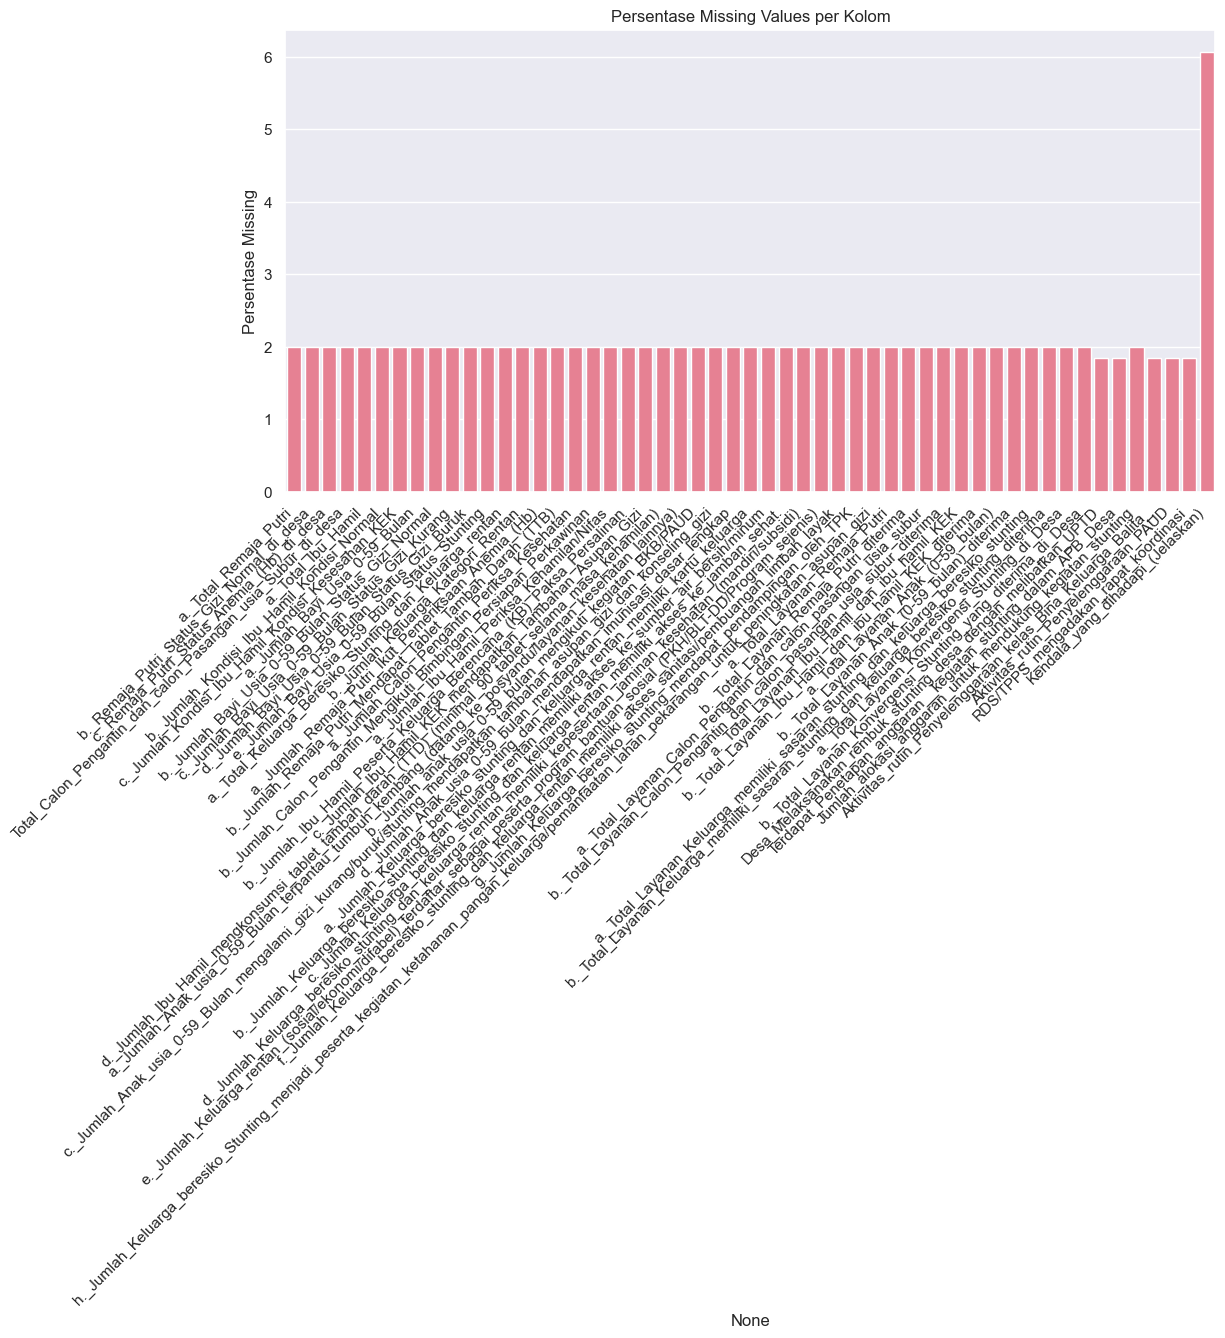

In [23]:
# Cek missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

# Tampilkan hanya kolom dengan missing values
missing_df = pd.DataFrame({
    'Jumlah Missing': missing,
    'Persentase Missing': missing_pct
})
missing_df = missing_df[missing_df['Jumlah Missing'] > 0]

print("🔍 Analisis Missing Values:")
display(missing_df)

# Visualisasi missing values
plt.figure(figsize=(12, 6))
sns.barplot(x=missing_df.index, y='Persentase Missing', data=missing_df)
plt.xticks(rotation=45, ha='right')
plt.title('Persentase Missing Values per Kolom')
plt.tight_layout()
plt.show()

## 3️⃣ Analisis Variabel Target (Skor Efektivitas)

Menganalisis distribusi dan karakteristik skor efektivitas sebagai variabel target.

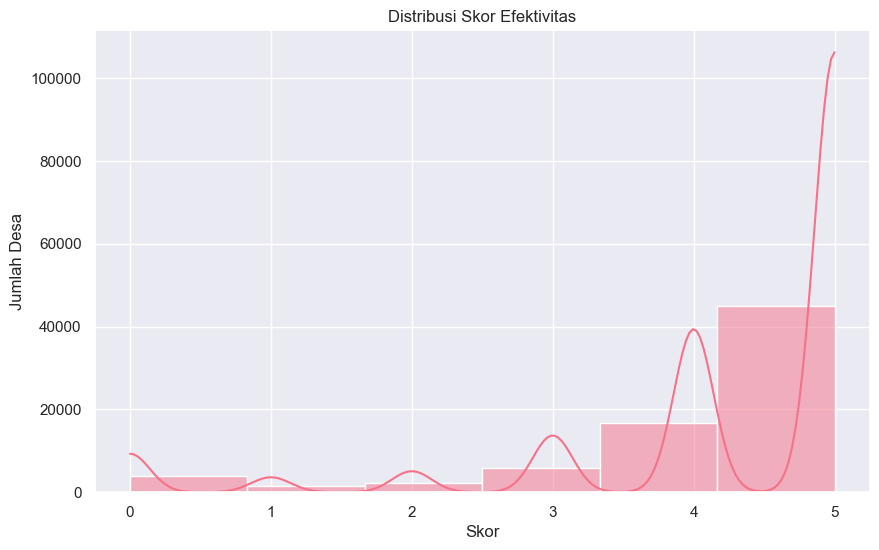


📊 Statistik Skor Efektivitas:


count   75264.00
mean        4.19
std         1.33
min         0.00
25%         4.00
50%         5.00
75%         5.00
max         5.00
Name: skor, dtype: float64

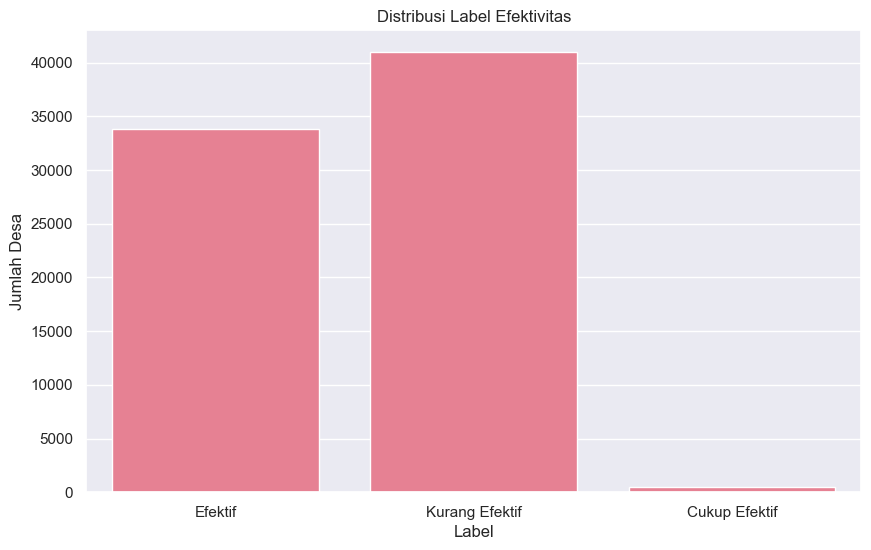

In [24]:
# Distribusi skor
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='skor', bins=6, kde=True)
plt.title('Distribusi Skor Efektivitas')
plt.xlabel('Skor')
plt.ylabel('Jumlah Desa')
plt.show()

# Statistik skor
print("\n📊 Statistik Skor Efektivitas:")
display(df['skor'].describe())

# Distribusi label efektivitas
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='label_efektivitas')
plt.title('Distribusi Label Efektivitas')
plt.xlabel('Label')
plt.ylabel('Jumlah Desa')
plt.show()

## 4️⃣ Analisis Anggaran

Menganalisis distribusi dan karakteristik anggaran program stunting.

💰 Statistik Anggaran:


count        73761.00
mean      32516475.83
std       68745240.45
min              0.00
25%              0.00
50%              0.00
75%       39000000.00
max     1811583522.00
Name: Jumlah_alokasi_anggaran_untuk_mendukung_kegiatan_stunting, dtype: float64


💵 Statistik Anggaran (Non-Zero):


count        35170.00
mean      68195842.31
std       86477748.34
min              1.00
25%       17000000.00
50%       41800000.00
75%       85613250.00
max     1811583522.00
Name: Jumlah_alokasi_anggaran_untuk_mendukung_kegiatan_stunting, dtype: float64

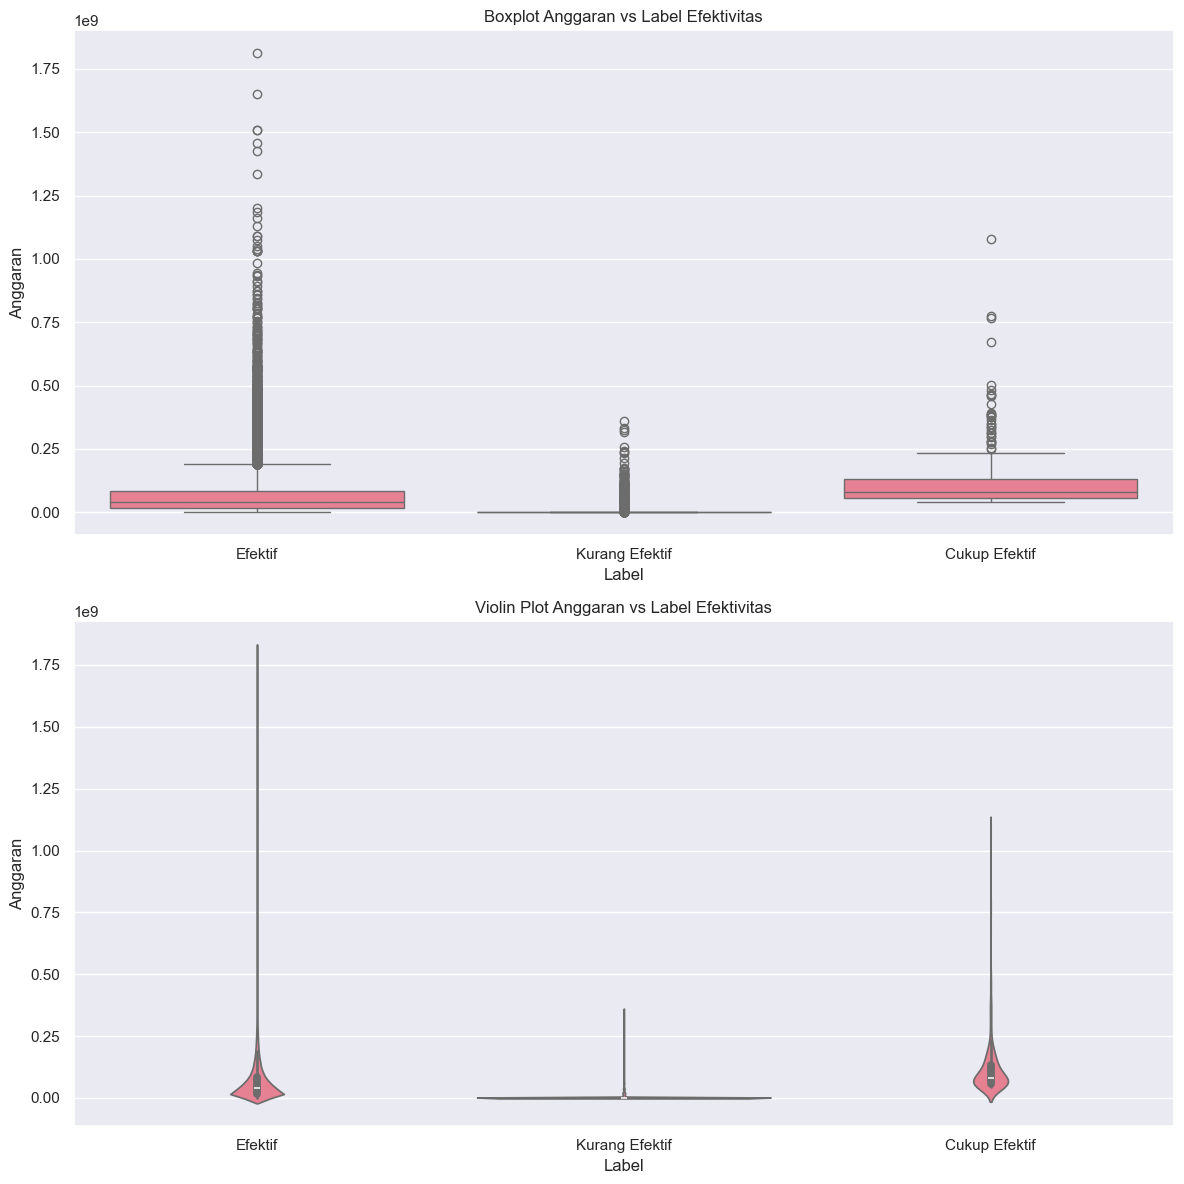

In [25]:
# Definisi kolom anggaran
budget_col = 'Jumlah_alokasi_anggaran_untuk_mendukung_kegiatan_stunting'

# Statistik anggaran
print("💰 Statistik Anggaran:")
display(df[budget_col].describe())

# Analisis anggaran non-zero
non_zero = df[df[budget_col] > 0][budget_col]
print("\n💵 Statistik Anggaran (Non-Zero):")
display(non_zero.describe())

# Visualisasi
fig, axes = plt.subplots(2, 1, figsize=(12, 12))

# Boxplot
sns.boxplot(data=df, x='label_efektivitas', y=budget_col, ax=axes[0])
axes[0].set_title('Boxplot Anggaran vs Label Efektivitas')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Anggaran')

# Violin plot untuk distribusi
sns.violinplot(data=df, x='label_efektivitas', y=budget_col, ax=axes[1])
axes[1].set_title('Violin Plot Anggaran vs Label Efektivitas')
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Anggaran')

plt.tight_layout()
plt.show()

## 5️⃣ Analisis Variabel Kategorikal

Menganalisis distribusi dan hubungan variabel kategorikal dengan skor efektivitas.

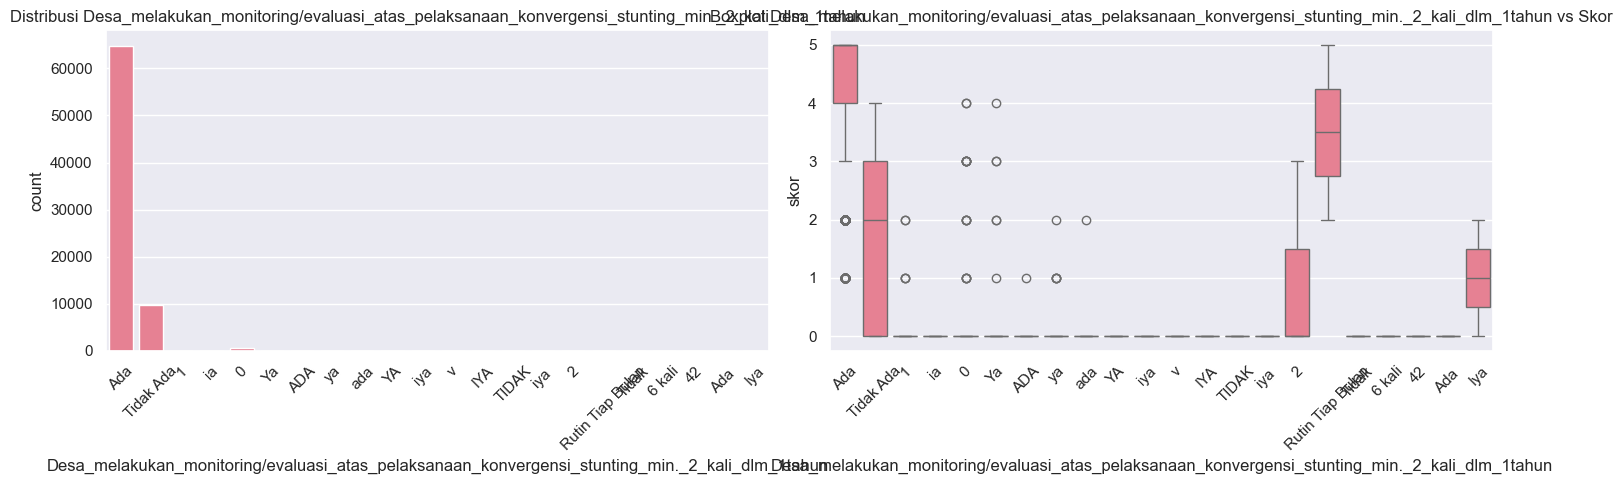


📊 Distribusi Desa_melakukan_monitoring/evaluasi_atas_pelaksanaan_konvergensi_stunting_min._2_kali_dlm_1tahun:


Desa_melakukan_monitoring/evaluasi_atas_pelaksanaan_konvergensi_stunting_min._2_kali_dlm_1tahun
Ada                86.15
Tidak Ada          12.92
0                   0.68
Ya                  0.06
1                   0.06
ya                  0.04
ada                 0.03
YA                  0.02
ADA                 0.01
2                   0.01
iya                 0.00
IYA                 0.00
Rutin Tiap Bulan    0.00
Iya                 0.00
iya                 0.00
TIDAK               0.00
ia                  0.00
Tidak               0.00
6 kali              0.00
42                  0.00
Ada                 0.00
v                   0.00
Name: proportion, dtype: float64

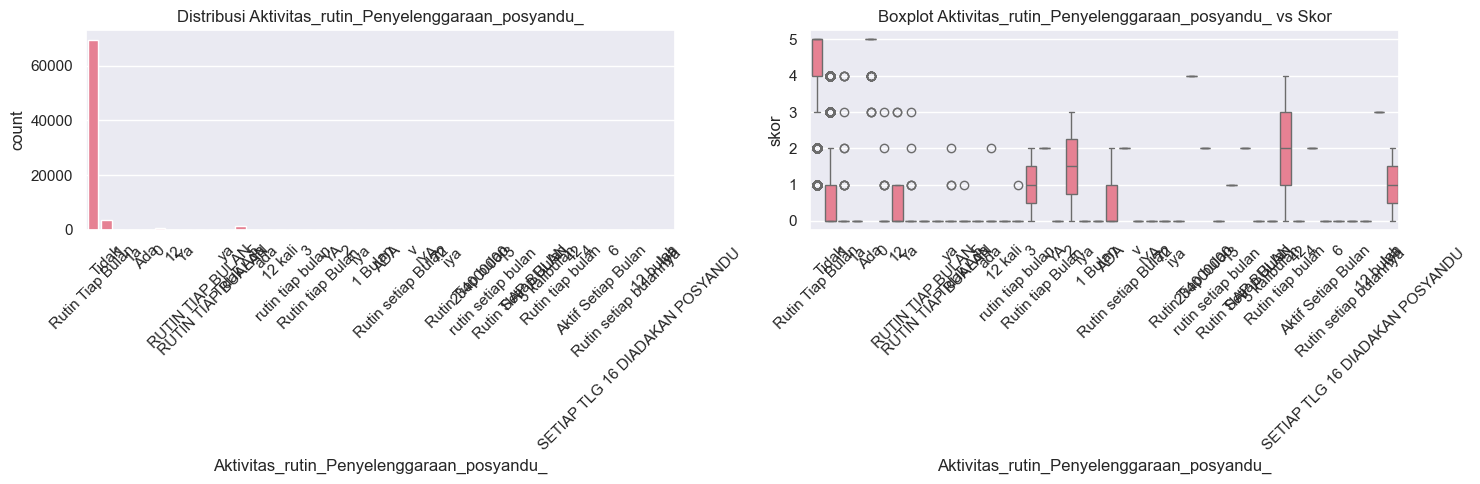


📊 Distribusi Aktivitas_rutin_Penyelenggaraan_posyandu_:


Aktivitas_rutin_Penyelenggaraan_posyandu_
Rutin Tiap Bulan                   92.23
Tidak                               4.87
Tidak Ada                           1.85
0                                   0.67
Ada                                 0.10
1                                   0.07
Ya                                  0.06
ya                                  0.03
YA                                  0.02
rutin tiap bulan                    0.01
ada                                 0.01
12                                  0.01
ADA                                 0.01
RUTIN TIAP BULAN                    0.01
IYA                                 0.00
iya                                 0.00
5                                   0.00
2                                   0.00
Rutin tiap bulan                    0.00
Rutin Tiap bulan                    0.00
Iya                                 0.00
3                                   0.00
TIAP BULAN                          0.00
12 bulah       

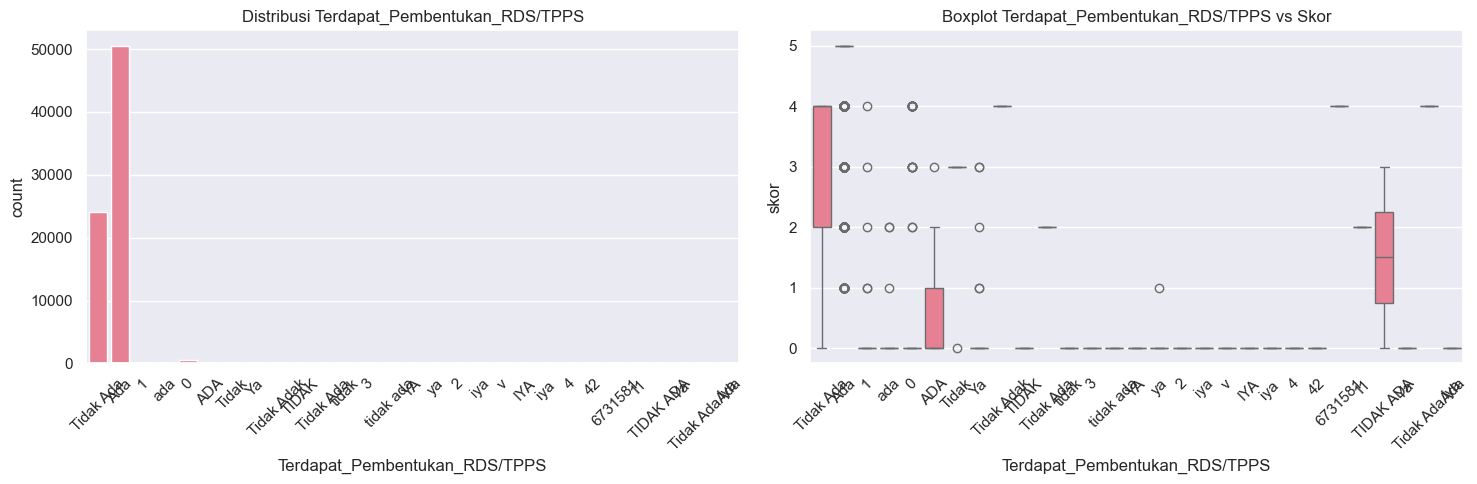


📊 Distribusi Terdapat_Pembentukan_RDS/TPPS:


Terdapat_Pembentukan_RDS/TPPS
Ada            67.04
Tidak Ada      32.02
0               0.70
Ya              0.06
1               0.05
ada             0.02
ya              0.02
YA              0.02
ADA             0.01
tidak           0.01
Tidak           0.01
tidak ada       0.01
iya             0.00
 Tidak Ada      0.00
2               0.00
TIDAK           0.00
IYA             0.00
TIDAK ADA       0.00
Tidak Adak      0.00
6731581         0.00
Tidak AdaAda    0.00
Ya              0.00
11              0.00
v               0.00
42              0.00
4               0.00
iya             0.00
3               0.00
Iya             0.00
Name: proportion, dtype: float64

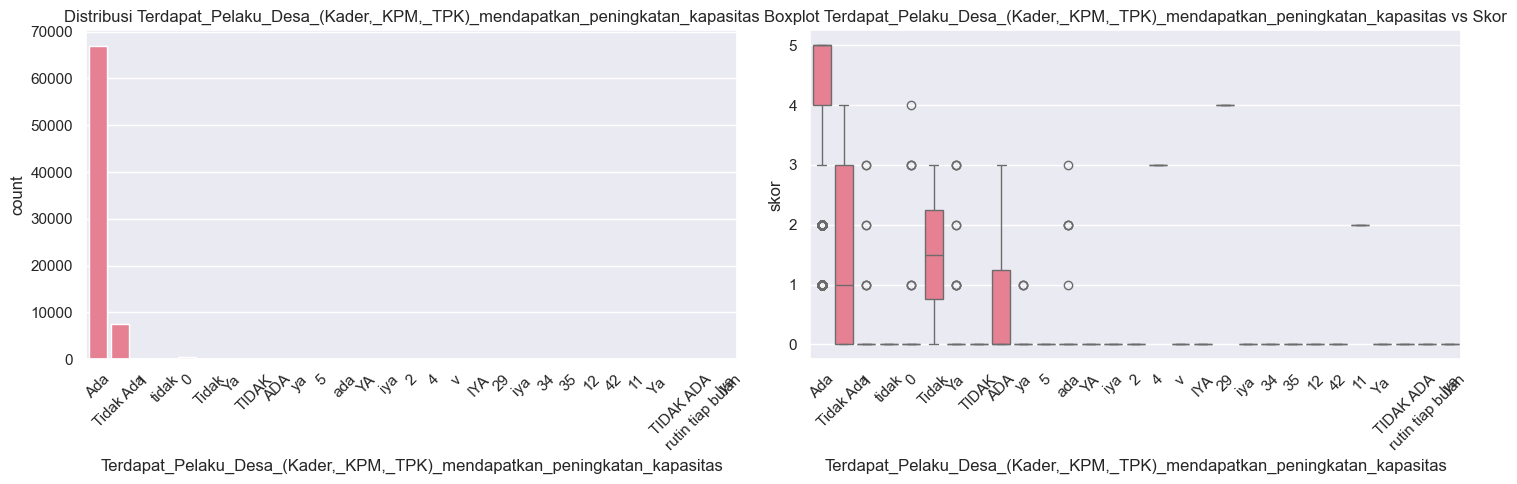


📊 Distribusi Terdapat_Pelaku_Desa_(Kader,_KPM,_TPK)_mendapatkan_peningkatan_kapasitas:


Terdapat_Pelaku_Desa_(Kader,_KPM,_TPK)_mendapatkan_peningkatan_kapasitas
Ada                88.92
Tidak Ada          10.14
0                   0.67
Ya                  0.07
1                   0.06
ada                 0.03
ya                  0.03
YA                  0.02
ADA                 0.02
IYA                 0.00
4                   0.00
iya                 0.00
2                   0.00
Tidak               0.00
5                   0.00
TIDAK               0.00
v                   0.00
tidak               0.00
29                  0.00
iya                 0.00
34                  0.00
35                  0.00
12                  0.00
42                  0.00
11                  0.00
Ya                  0.00
TIDAK ADA           0.00
rutin tiap bulan    0.00
Iya                 0.00
Name: proportion, dtype: float64

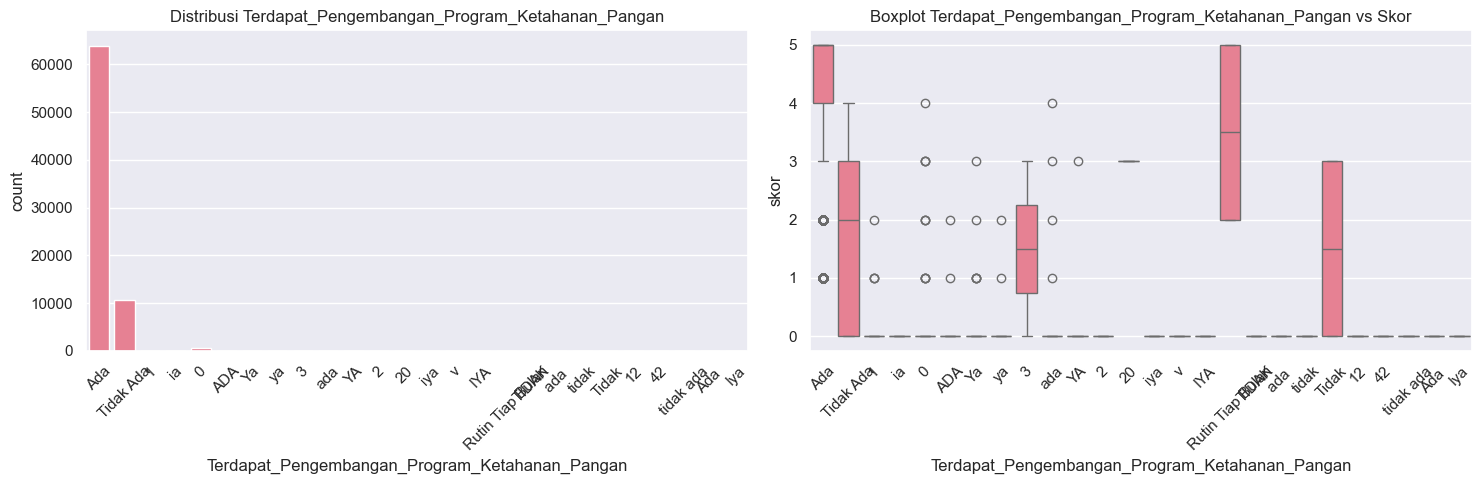


📊 Distribusi Terdapat_Pengembangan_Program_Ketahanan_Pangan:


Terdapat_Pengembangan_Program_Ketahanan_Pangan
Ada                84.90
Tidak Ada          14.17
0                   0.68
1                   0.06
Ya                  0.06
ada                 0.03
ya                  0.02
YA                  0.02
ADA                 0.02
tidak               0.01
Tidak               0.01
Rutin Tiap Bulan    0.01
IYA                 0.00
iya                 0.00
3                   0.00
v                   0.00
20                  0.00
2                   0.00
TIDAK               0.00
ada                 0.00
ia                  0.00
12                  0.00
42                  0.00
tidak ada           0.00
Ada                 0.00
Iya                 0.00
Name: proportion, dtype: float64

In [26]:
# Daftar variabel kategorikal
cat_features = [
    'Desa_melakukan_monitoring/evaluasi_atas_pelaksanaan_konvergensi_stunting_min._2_kali_dlm_1tahun',
    'Aktivitas_rutin_Penyelenggaraan_posyandu_',
    'Terdapat_Pembentukan_RDS/TPPS',
    'Terdapat_Pelaku_Desa_(Kader,_KPM,_TPK)_mendapatkan_peningkatan_kapasitas',
    'Terdapat_Pengembangan_Program_Ketahanan_Pangan'
]

# Analisis untuk setiap variabel kategorikal
for feature in cat_features:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Count plot
    sns.countplot(data=df, x=feature, ax=axes[0])
    axes[0].set_title(f'Distribusi {feature}')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Box plot terhadap skor
    sns.boxplot(data=df, x=feature, y='skor', ax=axes[1])
    axes[1].set_title(f'Boxplot {feature} vs Skor')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # Tampilkan tabel frekuensi
    print(f"\n📊 Distribusi {feature}:")
    display(df[feature].value_counts(normalize=True).mul(100).round(2))

## 6️⃣ Analisis Korelasi

Menganalisis hubungan antar variabel numerik menggunakan matriks korelasi.

C:\Users\mrizq\AppData\Local\Temp\ipykernel_18252\2755472728.py:8: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


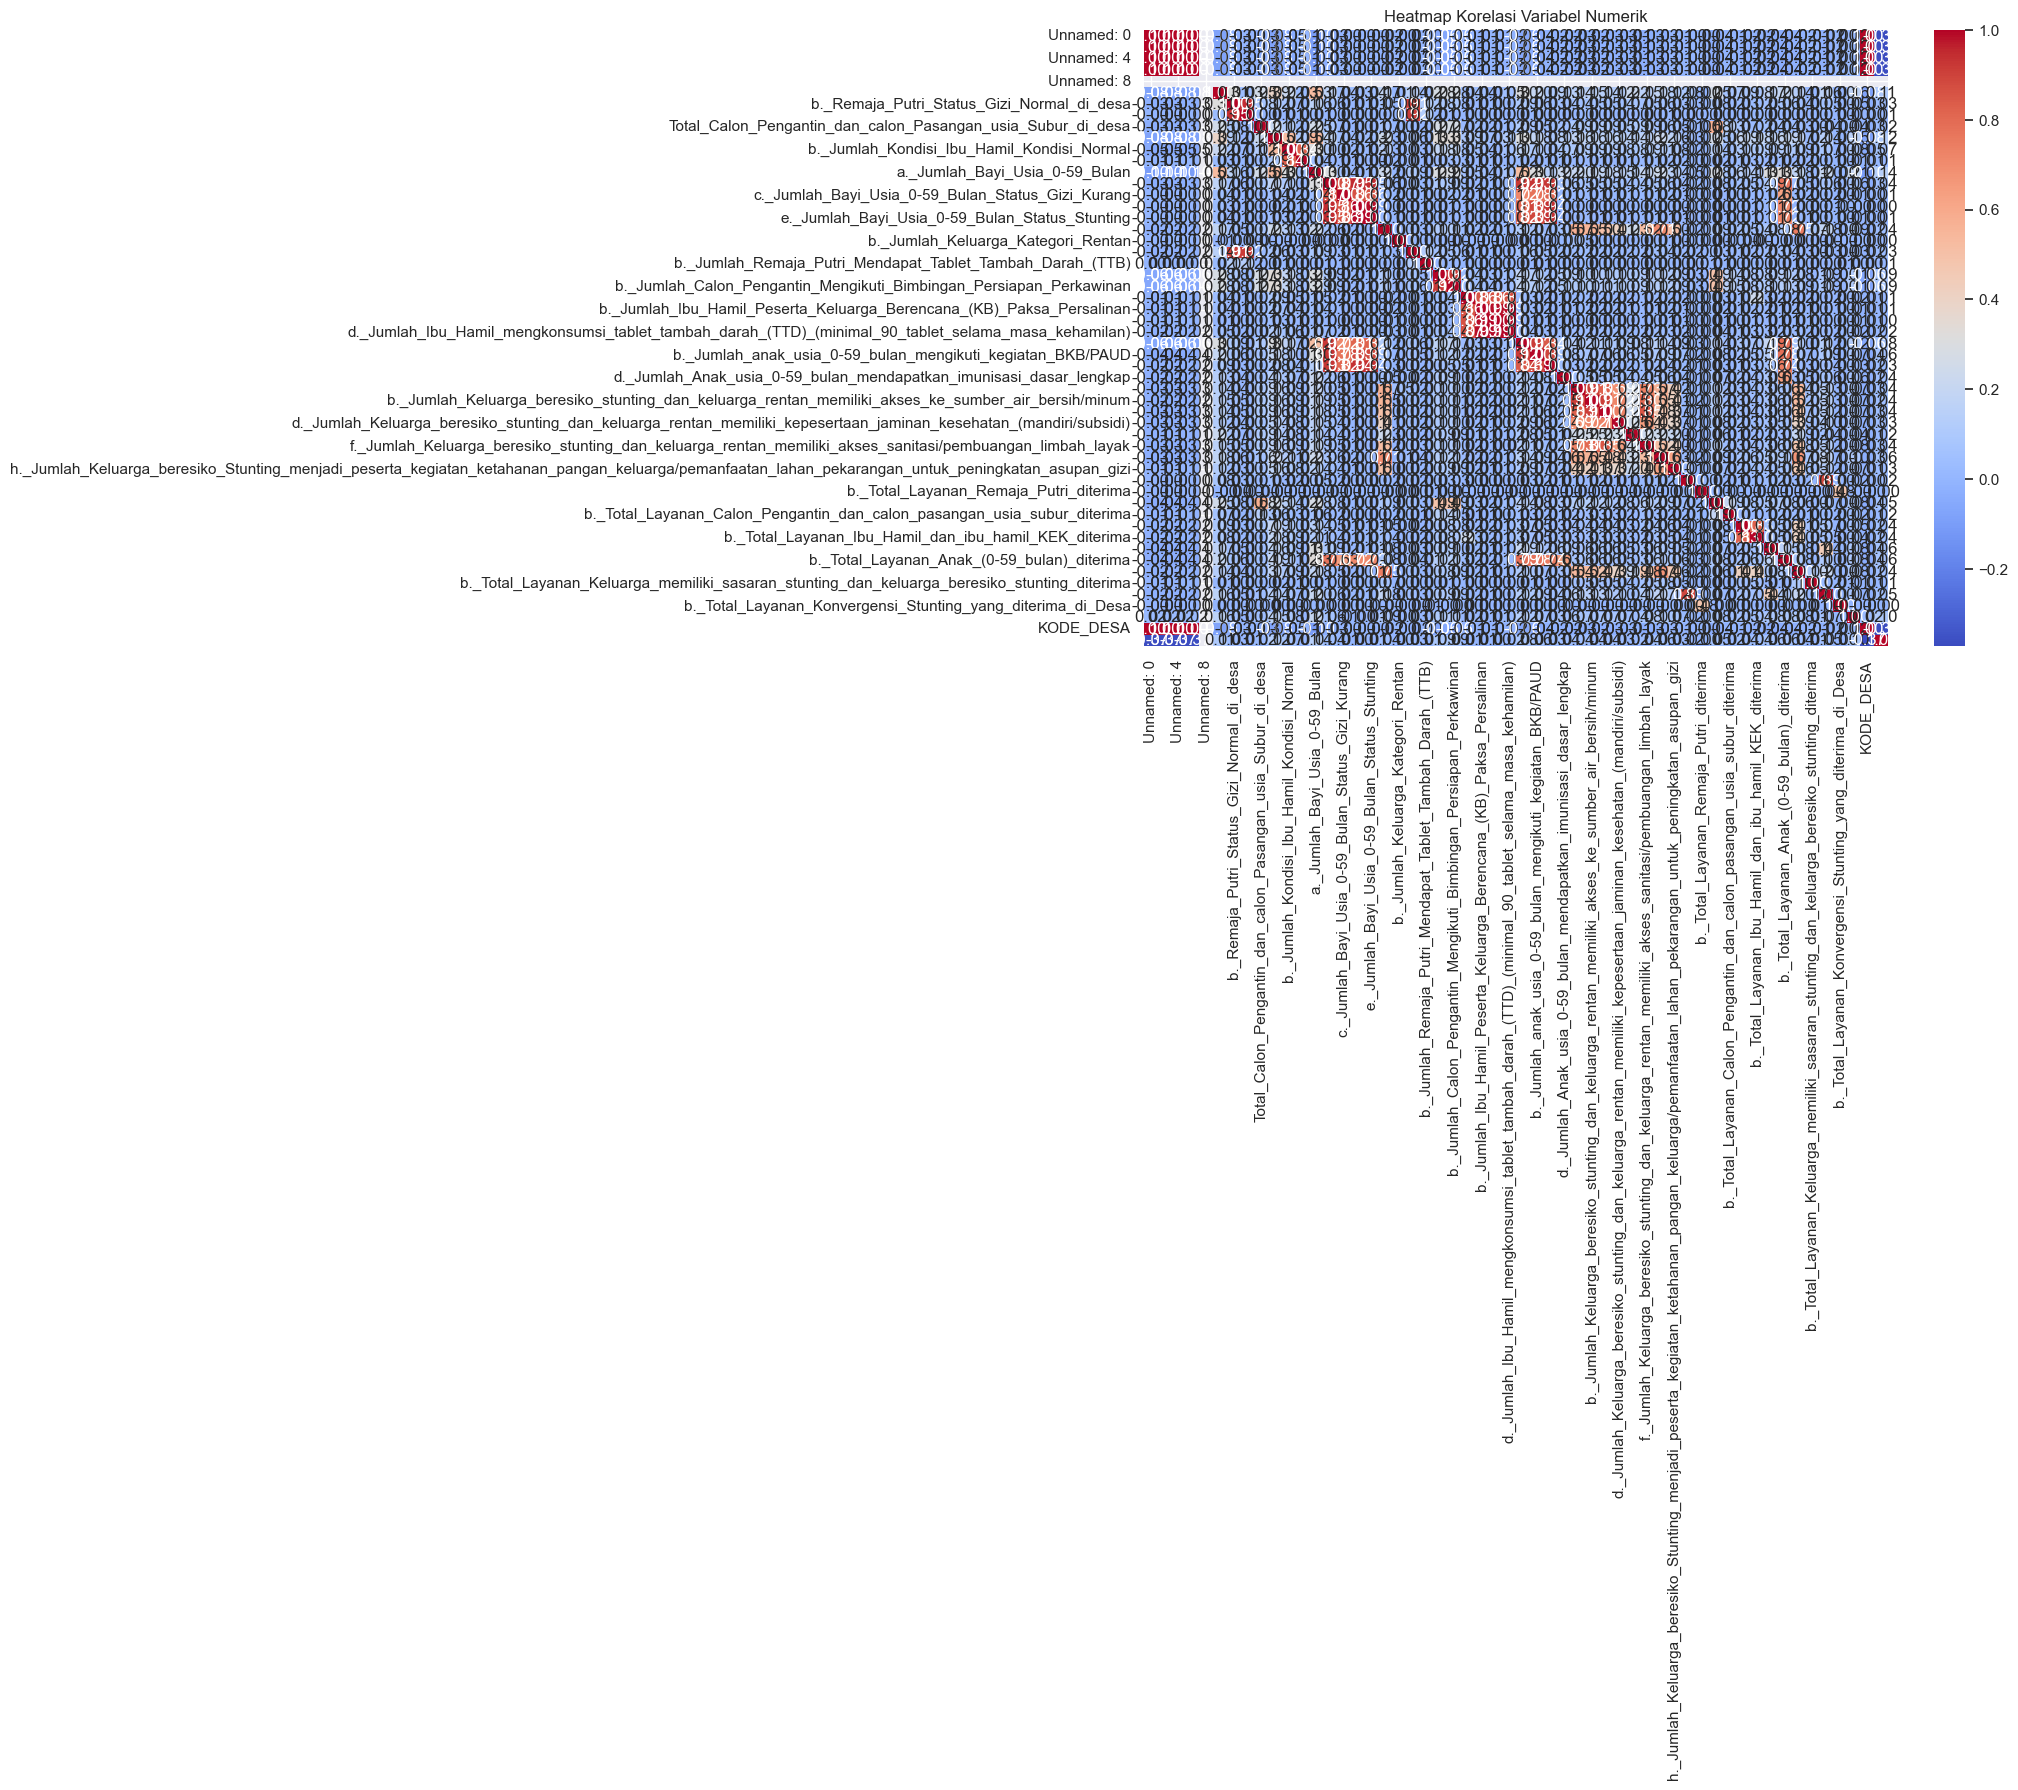


📊 Korelasi terhadap Skor:


skor                                                                                                                                                  1.00
a._Jumlah_Bayi_Usia_0-59_Bulan                                                                                                                        0.14
a._Total_Ibu_Hamil                                                                                                                                    0.12
a._Total_Remaja_Putri                                                                                                                                 0.11
Jumlah_alokasi_anggaran_untuk_mendukung_kegiatan_stunting                                                                                             0.10
b._Jumlah_Calon_Pengantin_Mengikuti_Bimbingan_Persiapan_Perkawinan                                                                                    0.09
a._Jumlah_Calon_Pengantin_Periksa_Kesehatan                           

In [27]:
# Hitung korelasi
corr = df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Heatmap Korelasi Variabel Numerik')
plt.tight_layout()
plt.show()

# Tampilkan korelasi terhadap skor
print("\n📊 Korelasi terhadap Skor:")
corr_skor = corr['skor'].sort_values(ascending=False)
display(corr_skor)

## 7️⃣ Feature Engineering

Membuat dan menganalisis fitur baru yang mungkin berguna untuk modeling.

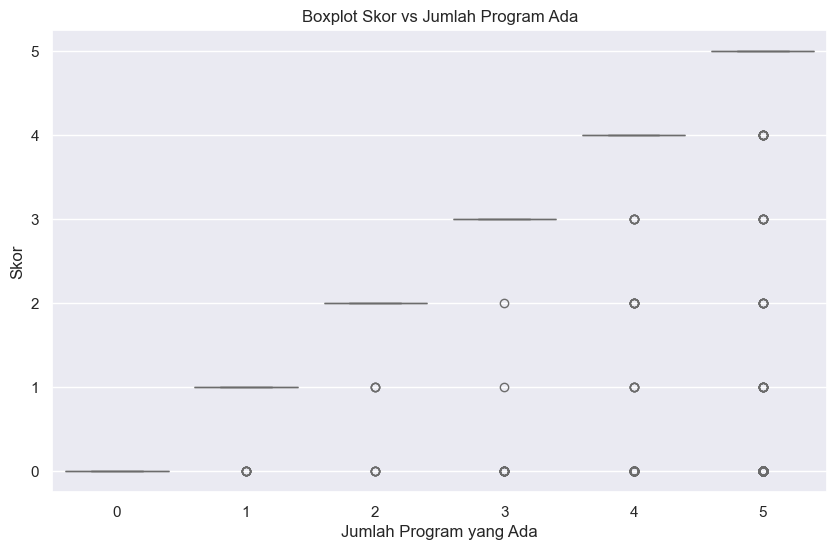


📊 Statistik Jumlah Program Ada:


count   75264.00
mean        4.20
std         1.32
min         0.00
25%         4.00
50%         5.00
75%         5.00
max         5.00
Name: jumlah_ada, dtype: float64

In [28]:
# Normalisasi variabel kategorikal
df_processed = normalize_kategorikal(df.copy(), cat_features)

# Tambah fitur baru
df_processed['jumlah_ada'] = (
    (df_processed[cat_features] == 'Ada').sum(axis=1) +
    (df_processed[cat_features] == 'Rutin Tiap Bulan').sum(axis=1)
)

# Analisis fitur baru
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_processed, x='jumlah_ada', y='skor')
plt.title('Boxplot Skor vs Jumlah Program Ada')
plt.xlabel('Jumlah Program yang Ada')
plt.ylabel('Skor')
plt.show()

# Statistik fitur baru
print("\n📊 Statistik Jumlah Program Ada:")
display(df_processed['jumlah_ada'].describe())

## 8️⃣ Kesimpulan dan Insight

### 📝 Temuan Utama

1. **Distribusi Skor**
   - Distribusi skor menunjukkan pola yang tidak seimbang (imbalanced)
   - Mayoritas desa memiliki skor efektivitas di kategori menengah (label 1)
   - Desa dengan skor efektivitas tinggi (label 2) dan rendah (label 0) memiliki jumlah yang lebih sedikit
   - Hal ini menunjukkan adanya ketimpangan dalam efektivitas program stunting antar desa

2. **Anggaran**
   - Terdapat variasi yang sangat besar dalam alokasi anggaran (std: 6.87e+07)
   - Sekitar 50% desa memiliki anggaran 0 (median: 0.00)
   - Untuk desa dengan anggaran non-zero:
     * Rata-rata anggaran: 68.2 juta
     * Median: 41.8 juta
     * 75% desa memiliki anggaran di bawah 85.6 juta
   - Teridentifikasi adanya outlier dengan anggaran sangat tinggi (max: 1.81 miliar)

3. **Program Intervensi**
   - Program Posyandu menunjukkan tingkat implementasi yang paling konsisten
   - Terdapat korelasi positif antara jumlah program yang diimplementasi ('jumlah_ada') dengan skor efektivitas
   - Desa dengan lebih banyak program aktif cenderung memiliki skor efektivitas yang lebih tinggi
   - Monitoring dan evaluasi berkala memiliki dampak positif terhadap efektivitas program

### 🎯 Rekomendasi untuk Modeling

1. **Preprocessing Data**
   - Perlu penanganan khusus untuk missing values (sekitar 1500 data per kolom)
   - Normalisasi anggaran diperlukan karena adanya outlier ekstrim
   - Rekomendasi transformasi anggaran:
     * Log transformation untuk mengatasi skewness
     * Atau kategorisasi menjadi kelompok anggaran (rendah, sedang, tinggi)

2. **Feature Engineering**
   - Pertahankan fitur 'jumlah_ada' karena menunjukkan korelasi yang baik dengan target
   - Buat fitur interaksi antara monitoring dan posyandu
   - Tambahkan fitur rasio realisasi program terhadap target
   - Kategorisasi anggaran bisa menjadi fitur yang lebih informatif daripada nilai nominal

3. **Pemilihan Model**
   - Gunakan teknik handling imbalanced data karena distribusi label tidak seimbang:
     * SMOTE
     * Class weights
     * Ensemble methods (Random Forest, XGBoost) dengan parameter yang sesuai
   - Fokus pada metrik evaluasi yang sesuai untuk imbalanced data:
     * F1-score
     * ROC-AUC
     * Precision-Recall curve
   - Pertimbangkan penggunaan model yang interpretable untuk memahami faktor-faktor yang mempengaruhi efektivitas